# Credit Card Fraud Detection — Exploratory Data Analysis
**Candidate 307394 | MSc Data Science Dissertation**

This notebook covers:
1. Environment setup & dataset loading
2. Dataset overview
3. Class imbalance analysis
4. Feature distributions (Amount, Time, PCA features)
5. Temporal analysis & concept drift check
6. Correlation analysis
7. Temporal train-test split construction
8. Preprocessing pipeline (StandardScaler)
9. EDA summary for dissertation write-up

---
**Dataset:** ULB/Kaggle European Credit Card Transactions  
**Source:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud  
**Place `creditcard.csv` in the same folder as this notebook before running.**

## 1. Environment Setup

In [2]:
# Install dependencies if needed (uncomment if running fresh)
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
FRAUD_COLOR   = '#D62728'   # red
LEGIT_COLOR   = '#1F77B4'   # blue
NEUTRAL_COLOR = '#7F7F7F'

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Dataset Loading & Overview

In [3]:
df = pd.read_csv("/kaggle/input/datasets/gagansinghbhatia/ulbkaggle-credit-card-dataset/creditcard.csv")

print('=== Dataset Shape ===')
print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
print()
print('=== Column Types ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values — clean dataset.')
print()
print('=== First 5 Rows ===')
df.head()

=== Dataset Shape ===
Rows: 284,807  |  Columns: 31

=== Column Types ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=== Missing Values ===
No missing values — clean dataset.

=== First 5 Rows ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Basic descriptive statistics for Amount and Time
print('=== Amount & Time Descriptive Statistics ===')
df[['Time', 'Amount', 'Class']].describe().round(4)

=== Amount & Time Descriptive Statistics ===


,Time,Amount,Class
count,284807.0000,284807.0000,284807.0000
mean,94813.8596,88.3496,0.0017
std,47488.1460,250.1201,0.0415
min,0.0000,0.0000,0.0000
25%,54201.5000,5.6000,0.0000
50%,84692.0000,22.0000,0.0000
75%,139320.5000,77.1650,0.0000
max,172792.0000,25691.1600,1.0000


## 3. Class Imbalance Analysis

=== Class Distribution ===
Total transactions :    284,807
Legitimate (0)     :    284,315  (99.8273%)
Fraudulent  (1)    :        492  (0.1727%)
Imbalance ratio    : 578:1


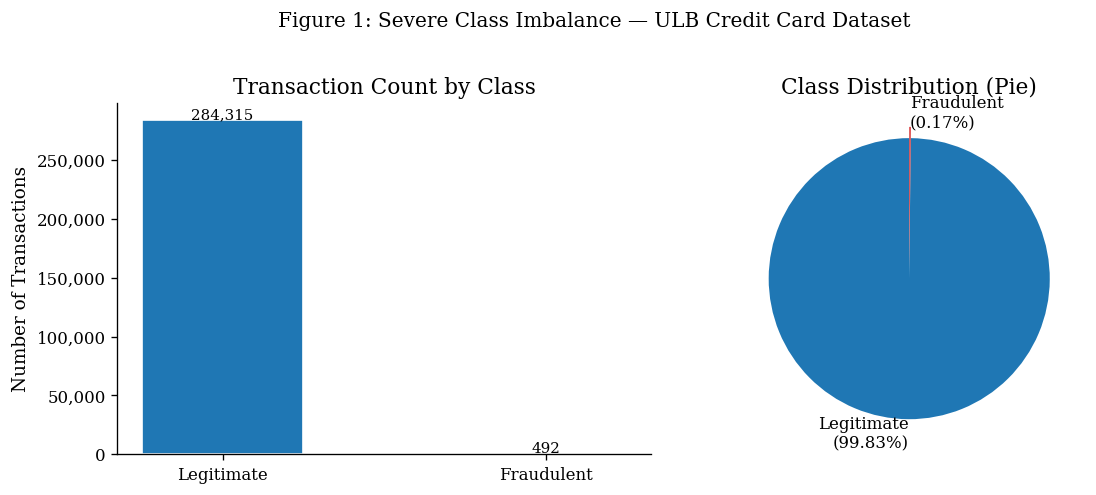

Saved: fig1_class_distribution.png


In [5]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

n_total  = len(df)
n_fraud  = len(fraud)
n_legit  = len(legit)
pct_fraud = n_fraud / n_total * 100

print('=== Class Distribution ===')
print(f'Total transactions : {n_total:>10,}')
print(f'Legitimate (0)     : {n_legit:>10,}  ({100-pct_fraud:.4f}%)')
print(f'Fraudulent  (1)    : {n_fraud:>10,}  ({pct_fraud:.4f}%)')
print(f'Imbalance ratio    : {n_legit/n_fraud:.0f}:1')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(['Legitimate', 'Fraudulent'], [n_legit, n_fraud],
            color=[LEGIT_COLOR, FRAUD_COLOR], width=0.5, edgecolor='white')
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Number of Transactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, v in enumerate([n_legit, n_fraud]):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

# Pie chart
axes[1].pie([n_legit, n_fraud],
            labels=[f'Legitimate\n({100-pct_fraud:.2f}%)', f'Fraudulent\n({pct_fraud:.2f}%)'],
            colors=[LEGIT_COLOR, FRAUD_COLOR],
            explode=[0, 0.08],
            startangle=90,
            textprops={'fontsize': 10})
axes[1].set_title('Class Distribution (Pie)')

plt.suptitle('Figure 1: Severe Class Imbalance — ULB Credit Card Dataset', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: fig1_class_distribution.png')

## 4. Feature Distribution Analysis

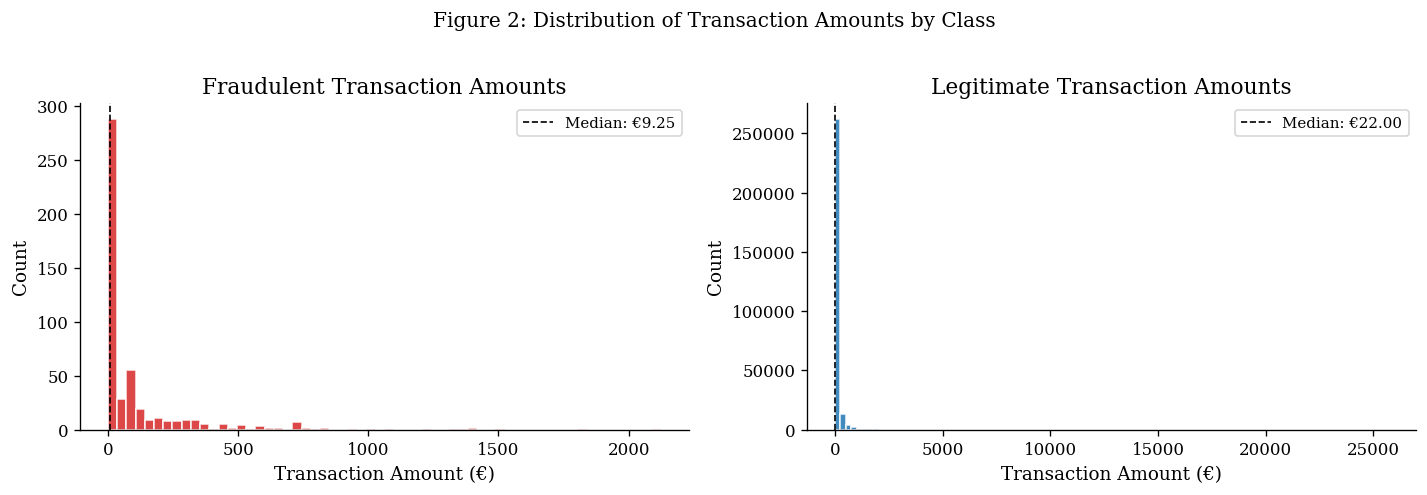

Amount stats — Fraudulent:
count     492.00
mean      122.21
std       256.68
min         0.00
25%         1.00
50%         9.25
75%       105.89
max      2125.87
Name: Amount, dtype: float64

Amount stats — Legitimate:
count    284315.00
mean         88.29
std         250.11
min           0.00
25%           5.65
50%          22.00
75%          77.05
max       25691.16
Name: Amount, dtype: float64


In [6]:
# --- 4a. Transaction Amount by Class ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram: fraud
axes[0].hist(fraud['Amount'], bins=60, color=FRAUD_COLOR, alpha=0.85, edgecolor='white')
axes[0].set_title('Fraudulent Transaction Amounts')
axes[0].set_xlabel('Transaction Amount (€)')
axes[0].set_ylabel('Count')
axes[0].axvline(fraud['Amount'].median(), color='black', linestyle='--', linewidth=1,
                label=f'Median: €{fraud["Amount"].median():.2f}')
axes[0].legend(fontsize=9)

# Histogram: legit (log scale for readability)
axes[1].hist(legit['Amount'], bins=100, color=LEGIT_COLOR, alpha=0.85, edgecolor='white')
axes[1].set_title('Legitimate Transaction Amounts')
axes[1].set_xlabel('Transaction Amount (€)')
axes[1].set_ylabel('Count')
axes[1].axvline(legit['Amount'].median(), color='black', linestyle='--', linewidth=1,
                label=f'Median: €{legit["Amount"].median():.2f}')
axes[1].legend(fontsize=9)

plt.suptitle('Figure 2: Distribution of Transaction Amounts by Class', y=1.02)
plt.tight_layout()
plt.savefig('fig2_amount_distribution.png', bbox_inches='tight')
plt.show()

# Descriptive stats
print('Amount stats — Fraudulent:')
print(fraud['Amount'].describe().round(2))
print()
print('Amount stats — Legitimate:')
print(legit['Amount'].describe().round(2))

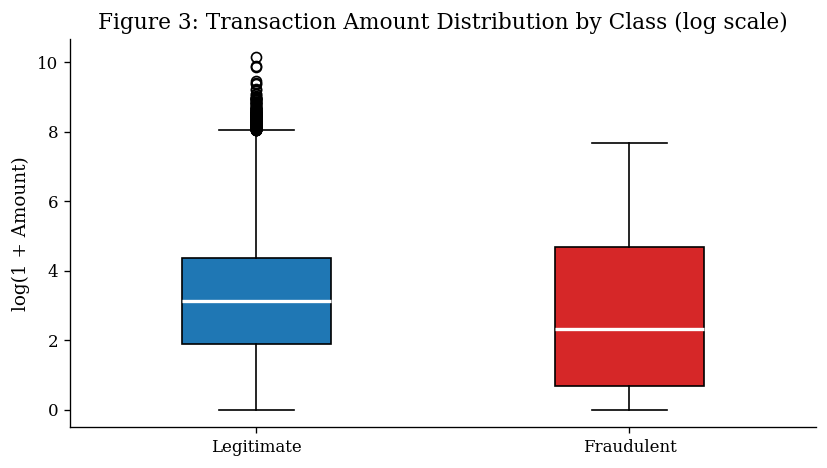

In [7]:
# --- 4b. Boxplot: Amount by Class (log scale) ---
df['log_amount'] = np.log1p(df['Amount'])  # log(1+x) to handle zeros
fraud = df[df['Class'] == 1]   # refresh to include new column
legit = df[df['Class'] == 0]   # refresh to include new column

fig, ax = plt.subplots(figsize=(7, 4))
bp_data = [legit['log_amount'], fraud['log_amount']]
bp = ax.boxplot(bp_data, patch_artist=True, widths=0.4,
                medianprops={'color': 'white', 'linewidth': 2})
bp['boxes'][0].set_facecolor(LEGIT_COLOR)
bp['boxes'][1].set_facecolor(FRAUD_COLOR)
ax.set_xticklabels(['Legitimate', 'Fraudulent'])
ax.set_ylabel('log(1 + Amount)')
ax.set_title('Figure 3: Transaction Amount Distribution by Class (log scale)')
plt.tight_layout()
plt.savefig('fig3_amount_boxplot.png', bbox_inches='tight')
plt.show()

## 5. Temporal Analysis & Concept Drift Check

In [8]:
# Convert Time (seconds since first transaction) to hours
df['Time_hours'] = df['Time'] / 3600
fraud = df[df['Class'] == 1]   # refresh to include new column
legit = df[df['Class'] == 0]   # refresh to include new column

print(f'Dataset spans: {df["Time_hours"].min():.1f}h to {df["Time_hours"].max():.1f}h')
print(f'Total duration : ~{df["Time_hours"].max()/24:.1f} days')
print(f'\nDay 1: 0 – 24h   ({len(df[df["Time_hours"] <= 24]):,} transactions)')
print(f'Day 2: 24 – 48h  ({len(df[df["Time_hours"] > 24]):,} transactions)')

Dataset spans: 0.0h to 48.0h
Total duration : ~2.0 days

Day 1: 0 – 24h   (144,787 transactions)
Day 2: 24 – 48h  (140,020 transactions)


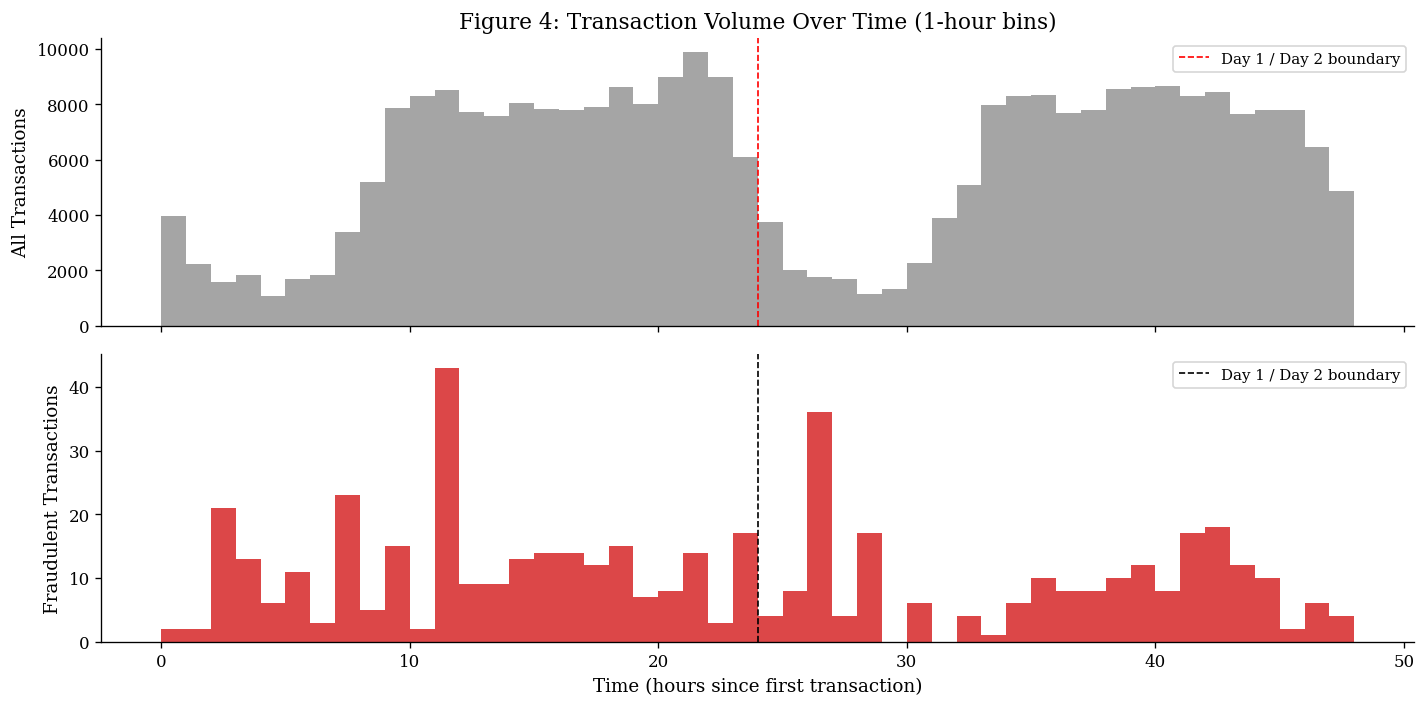

In [9]:
# --- Transaction volume over time ---
BIN_HOURS = 1  # 1-hour bins
bins = np.arange(0, df['Time_hours'].max() + BIN_HOURS, BIN_HOURS)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# All transactions
axes[0].hist(df['Time_hours'], bins=bins, color=NEUTRAL_COLOR, alpha=0.7, edgecolor='none')
axes[0].set_ylabel('All Transactions')
axes[0].set_title('Figure 4: Transaction Volume Over Time (1-hour bins)')
axes[0].axvline(24, color='red', linestyle='--', linewidth=1, label='Day 1 / Day 2 boundary')
axes[0].legend(fontsize=9)

# Fraud only
axes[1].hist(fraud['Time_hours'], bins=bins, color=FRAUD_COLOR, alpha=0.85, edgecolor='none')
axes[1].set_ylabel('Fraudulent Transactions')
axes[1].set_xlabel('Time (hours since first transaction)')
axes[1].axvline(24, color='black', linestyle='--', linewidth=1, label='Day 1 / Day 2 boundary')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig4_temporal_volume.png', bbox_inches='tight')
plt.show()

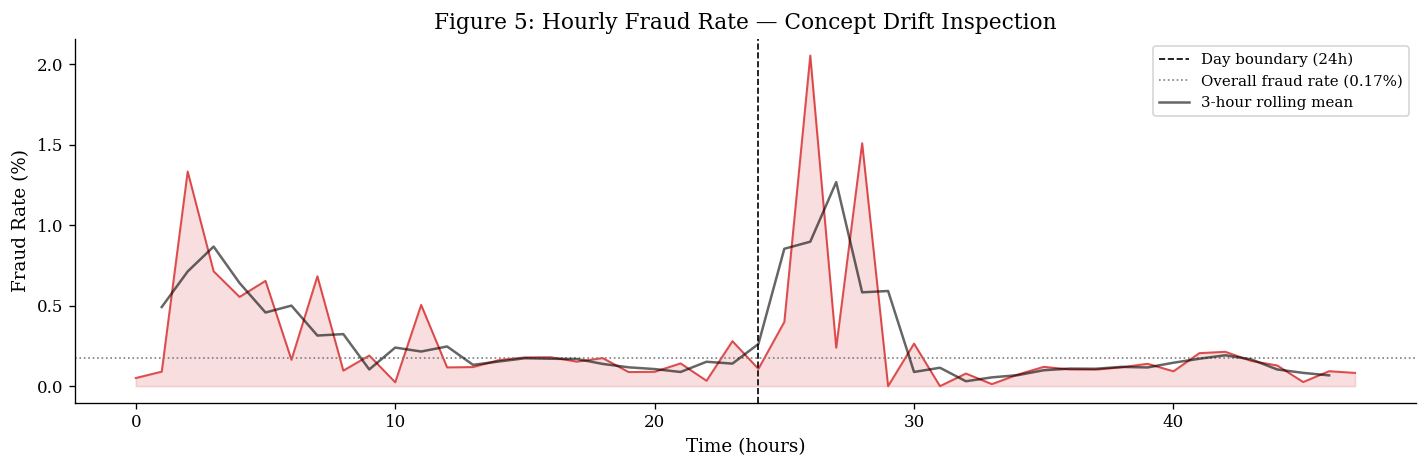

Day 1 fraud rate: 0.1941%
Day 2 fraud rate: 0.1507%
Difference: 0.0434 percentage points

Dissertation note: The 2-day window limits the ability to detect substantial concept drift.
Any observed rate variation may reflect daily patterns (e.g. night-time vs daytime)
rather than genuine long-term fraud pattern evolution (Topal et al., 2025).


In [10]:
# --- Concept drift check: fraud RATE per hour ---
# If concept drift is present, we expect the fraud rate to shift across hours
df['time_bin'] = pd.cut(df['Time_hours'], bins=bins, labels=False)
fraud_rate = df.groupby('time_bin').apply(
    lambda x: x['Class'].sum() / len(x) * 100
).reset_index()
fraud_rate.columns = ['time_bin', 'fraud_rate_pct']
fraud_rate['time_hours'] = fraud_rate['time_bin'] * BIN_HOURS

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fraud_rate['time_hours'], fraud_rate['fraud_rate_pct'],
        color=FRAUD_COLOR, linewidth=1.2, alpha=0.8)
ax.fill_between(fraud_rate['time_hours'], fraud_rate['fraud_rate_pct'],
                alpha=0.15, color=FRAUD_COLOR)
ax.axvline(24, color='black', linestyle='--', linewidth=1, label='Day boundary (24h)')
ax.axhline(pct_fraud, color=NEUTRAL_COLOR, linestyle=':', linewidth=1,
           label=f'Overall fraud rate ({pct_fraud:.2f}%)')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Figure 5: Hourly Fraud Rate — Concept Drift Inspection')
ax.legend(fontsize=9)

# Rolling average to highlight trend
rolling = fraud_rate['fraud_rate_pct'].rolling(window=3, center=True).mean()
ax.plot(fraud_rate['time_hours'], rolling, color='black', linewidth=1.5,
        linestyle='-', label='3-hour rolling mean', alpha=0.6)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig5_fraud_rate_over_time.png', bbox_inches='tight')
plt.show()

# Dissertation note
day1_rate = df[df['Time_hours'] <= 24]['Class'].mean() * 100
day2_rate = df[df['Time_hours'] > 24]['Class'].mean() * 100
print(f'Day 1 fraud rate: {day1_rate:.4f}%')
print(f'Day 2 fraud rate: {day2_rate:.4f}%')
print(f'Difference: {abs(day1_rate - day2_rate):.4f} percentage points')
print()
print('Dissertation note: The 2-day window limits the ability to detect substantial concept drift.')
print('Any observed rate variation may reflect daily patterns (e.g. night-time vs daytime)')
print('rather than genuine long-term fraud pattern evolution (Topal et al., 2025).')

## 6. PCA Feature Analysis

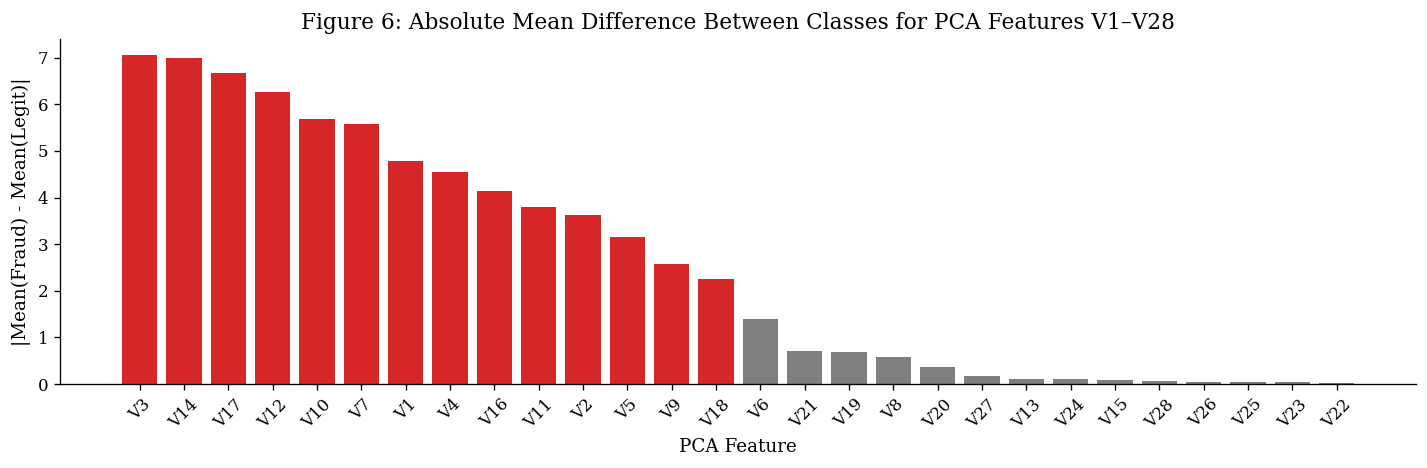

Top 5 most discriminating features by mean difference:
V3     7.045452
V14    6.983787
V17    6.677371
V12    6.270225
V10    5.686707
dtype: float64


In [11]:
# --- Distribution of PCA features V1-V28: mean comparison by class ---
pca_cols = [f'V{i}' for i in range(1, 29)]

fraud_means = fraud[pca_cols].mean()
legit_means = legit[pca_cols].mean()
diff_means  = (fraud_means - legit_means).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
colors = [FRAUD_COLOR if v > diff_means.median() else NEUTRAL_COLOR for v in diff_means.values]
ax.bar(diff_means.index, diff_means.values, color=colors, edgecolor='none')
ax.set_xlabel('PCA Feature')
ax.set_ylabel('|Mean(Fraud) - Mean(Legit)|')
ax.set_title('Figure 6: Absolute Mean Difference Between Classes for PCA Features V1–V28')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('fig6_pca_mean_diff.png', bbox_inches='tight')
plt.show()

print('Top 5 most discriminating features by mean difference:')
print(diff_means.head())

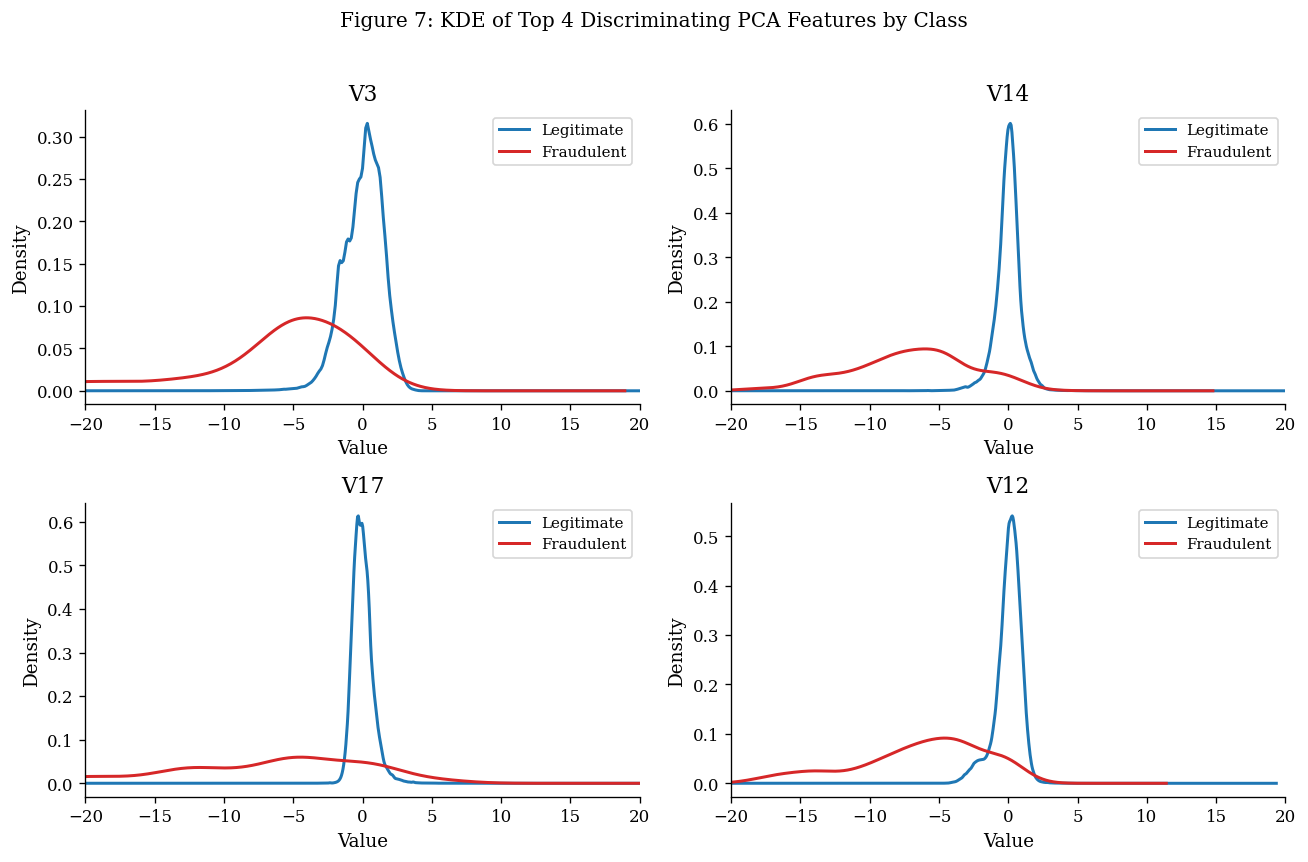

In [12]:
# --- KDE plots for top 4 discriminating features ---
top_features = diff_means.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    legit[feat].plot.kde(ax=axes[i], color=LEGIT_COLOR, label='Legitimate', linewidth=1.8)
    fraud[feat].plot.kde(ax=axes[i], color=FRAUD_COLOR, label='Fraudulent', linewidth=1.8)
    axes[i].set_title(f'{feat}')
    axes[i].set_xlabel('Value')
    axes[i].legend(fontsize=9)
    axes[i].set_xlim([-20, 20])

plt.suptitle('Figure 7: KDE of Top 4 Discriminating PCA Features by Class', y=1.02)
plt.tight_layout()
plt.savefig('fig7_pca_kde.png', bbox_inches='tight')
plt.show()

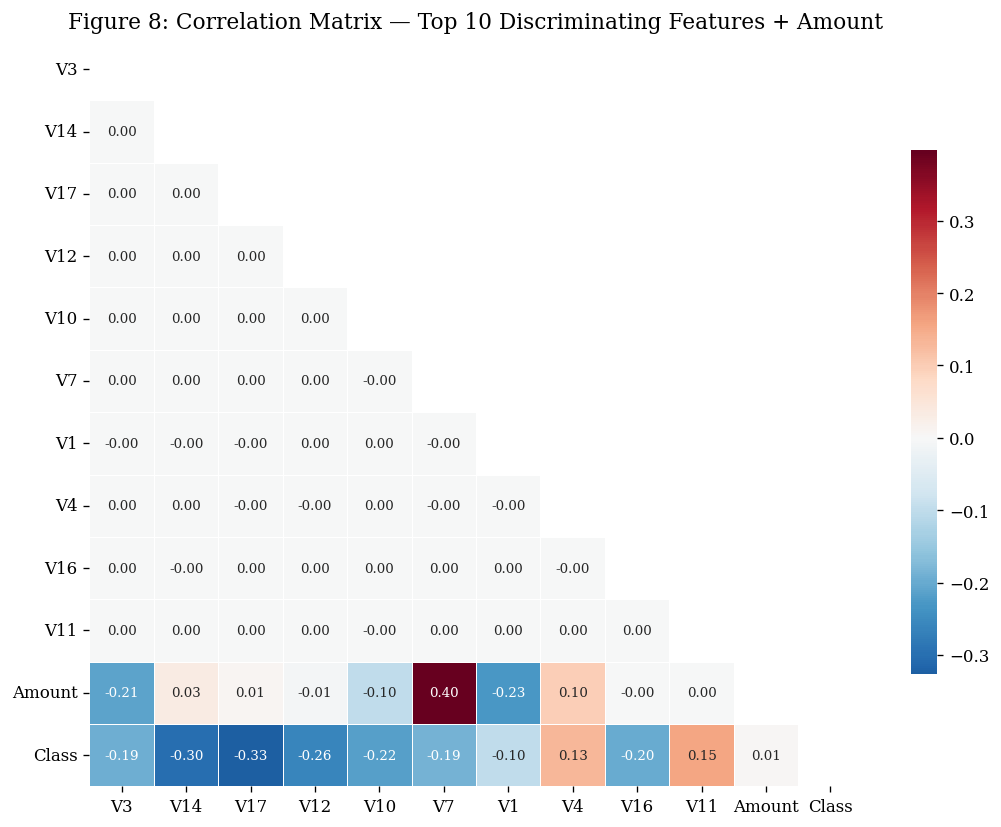

In [13]:
# --- Correlation heatmap (fraud class only, top features) ---
top10 = diff_means.head(10).index.tolist() + ['Amount', 'Class']
corr = df[top10].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 8})
ax.set_title('Figure 8: Correlation Matrix — Top 10 Discriminating Features + Amount')
plt.tight_layout()
plt.savefig('fig8_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 7. Temporal Train-Test Split Construction

=== Temporal Train-Test Split ===
Split point    : row 227,845 / Time = 145248s (40.3h)

Train set size : 227,845 (80.0%)
  Fraud        : 417 (0.1830%)

Test  set size : 56,962 (20.0%)
  Fraud        : 75 (0.1317%)


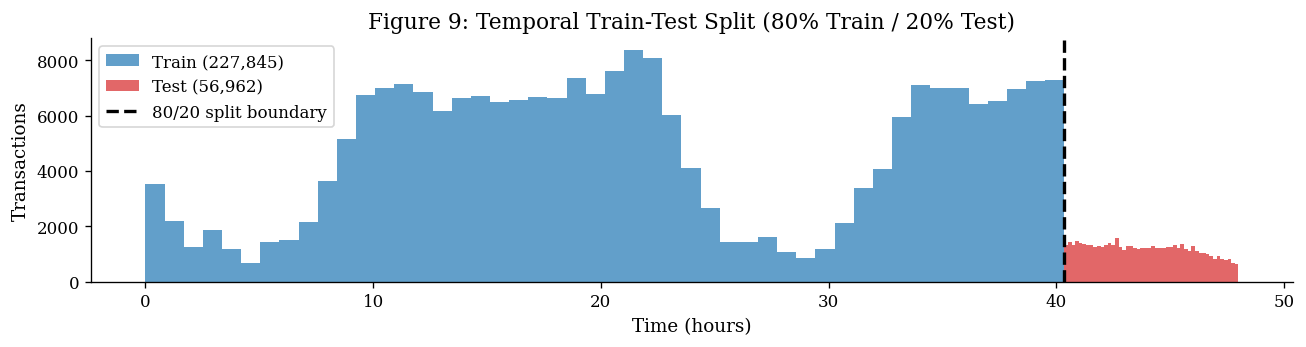

In [14]:
# Sort by Time to ensure chronological order
df_sorted = df.sort_values('Time').reset_index(drop=True)

# Temporal split: 80% train, 20% test
SPLIT_RATIO = 0.80
split_idx = int(len(df_sorted) * SPLIT_RATIO)
split_time = df_sorted.iloc[split_idx]['Time']

train_df = df_sorted.iloc[:split_idx].copy()
test_df  = df_sorted.iloc[split_idx:].copy()

print('=== Temporal Train-Test Split ===')
print(f'Split point    : row {split_idx:,} / Time = {split_time:.0f}s ({split_time/3600:.1f}h)')
print()
print(f'Train set size : {len(train_df):,} ({len(train_df)/len(df_sorted)*100:.1f}%)')
print(f'  Fraud        : {train_df["Class"].sum()} ({train_df["Class"].mean()*100:.4f}%)')
print()
print(f'Test  set size : {len(test_df):,} ({len(test_df)/len(df_sorted)*100:.1f}%)')
print(f'  Fraud        : {test_df["Class"].sum()} ({test_df["Class"].mean()*100:.4f}%)')

# Visualise the split
fig, ax = plt.subplots(figsize=(11, 3))
ax.hist(train_df['Time_hours'] if 'Time_hours' in train_df.columns else train_df['Time']/3600,
        bins=48, color=LEGIT_COLOR, alpha=0.7, label=f'Train ({len(train_df):,})')
ax.hist(test_df['Time_hours'] if 'Time_hours' in test_df.columns else test_df['Time']/3600,
        bins=48, color=FRAUD_COLOR, alpha=0.7, label=f'Test ({len(test_df):,})')
ax.axvline(split_time/3600, color='black', linestyle='--', linewidth=2, label='80/20 split boundary')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Transactions')
ax.set_title('Figure 9: Temporal Train-Test Split (80% Train / 20% Test)')
ax.legend()
plt.tight_layout()
plt.savefig('fig9_temporal_split.png', bbox_inches='tight')
plt.show()

## 8. Preprocessing Pipeline

In [15]:
# Drop helper columns before modelling
drop_cols = ['Time_hours', 'log_amount', 'time_bin']
train_clean = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
test_clean  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])

# Feature matrix and labels
FEATURES = [c for c in train_clean.columns if c != 'Class']
TARGET   = 'Class'

X_train = train_clean[FEATURES].copy()
y_train = train_clean[TARGET].copy()
X_test  = test_clean[FEATURES].copy()
y_test  = test_clean[TARGET].copy()

# StandardScaler on Amount and Time only
# (V1-V28 are already PCA-scaled; do NOT re-scale them)
scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']]  = scaler.transform(X_test[['Time', 'Amount']])   # fit on train only!

print('=== Preprocessing Complete ===')
print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}  |  fraud: {y_train.sum()}')
print(f'X_test : {X_test.shape}  |  y_test : {y_test.shape}   |  fraud: {y_test.sum()}')
print()
print('Amount and Time scaled. V1-V28 left as-is.')
print()
print('After scaling — Amount (train):')
print(X_train['Amount'].describe().round(4))

=== Preprocessing Complete ===
X_train: (227845, 30)  |  y_train: (227845,)  |  fraud: 417
X_test : (56962, 30)  |  y_test : (56962,)   |  fraud: 75

Amount and Time scaled. V1-V28 left as-is.

After scaling — Amount (train):
count    227845.0000
mean         -0.0000
std           1.0000
min          -0.3626
25%          -0.3386
50%          -0.2692
75%          -0.0433
max          78.1056
Name: Amount, dtype: float64


In [16]:
# Save preprocessed splits for use in Phase 2 modelling notebook
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv',   index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv',   index=False)

print('Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv')
print('These are the canonical inputs for all Phase 2 modelling experiments.')

Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv
These are the canonical inputs for all Phase 2 modelling experiments.


## 9. EDA Summary for Dissertation Write-Up

In [17]:
print('='*60)
print('EDA SUMMARY — KEY FINDINGS FOR DISSERTATION')
print('='*60)
print()
print('Dataset:')
print(f'  284,807 transactions over ~48 hours (September 2013)')
print(f'  492 fraudulent ({pct_fraud:.4f}%) — severe class imbalance')
print(f'  No missing values; 28 PCA features + Time + Amount')
print()
print('Class imbalance:')
print(f'  Imbalance ratio: {int(n_legit/n_fraud):,}:1 (legitimate:fraudulent)')
print(f'  A naive all-legitimate classifier achieves {100-pct_fraud:.2f}% accuracy')
print(f'  => Accuracy is not a valid evaluation metric (Btoush et al., 2023)')
print()
print('Amount distribution:')
print(f'  Fraud  — median: €{fraud["Amount"].median():.2f}, max: €{fraud["Amount"].max():.2f}')
print(f'  Legit  — median: €{legit["Amount"].median():.2f}, max: €{legit["Amount"].max():.2f}')
print(f'  Fraudulent transactions cluster at lower amounts')
print(f'  Amount is right-skewed => StandardScaler normalisation applied')
print()
print('Temporal patterns:')
print(f'  Day 1 fraud rate: {day1_rate:.4f}%')
print(f'  Day 2 fraud rate: {day2_rate:.4f}%')
print(f'  Difference: {abs(day1_rate-day2_rate):.4f}pp')
print(f'  Concept drift: limited evidence within 2-day window')
print(f'  Daily patterns (night vs daytime) may confound temporal analysis')
print(f'  => Acknowledged as limitation in dissertation (Topal et al., 2025)')
print()
print('Most discriminating PCA features:')
for feat, val in diff_means.head(5).items():
    print(f'  {feat}: |mean diff| = {val:.4f}')
print()
print('Train-test split:')
print(f'  Temporal 80/20: {len(train_df):,} train / {len(test_df):,} test')
print(f'  Split boundary: {split_time/3600:.1f}h')
print(f'  Fraud in train: {y_train.sum()} | Fraud in test: {y_test.sum()}')
print()
print('Preprocessing applied:')
print('  StandardScaler on Time and Amount (fit on train only)')
print('  V1-V28 left unscaled (already PCA-transformed)')
print('  No imputation required (zero missing values)')
print()
print('Outputs saved:')
print('  X_train.csv, X_test.csv, y_train.csv, y_test.csv')
print('  fig1_class_distribution.png through fig9_temporal_split.png')

EDA SUMMARY — KEY FINDINGS FOR DISSERTATION

Dataset:
  284,807 transactions over ~48 hours (September 2013)
  492 fraudulent (0.1727%) — severe class imbalance
  No missing values; 28 PCA features + Time + Amount

Class imbalance:
  Imbalance ratio: 577:1 (legitimate:fraudulent)
  A naive all-legitimate classifier achieves 99.83% accuracy
  => Accuracy is not a valid evaluation metric (Btoush et al., 2023)

Amount distribution:
  Fraud  — median: €9.25, max: €2125.87
  Legit  — median: €22.00, max: €25691.16
  Fraudulent transactions cluster at lower amounts
  Amount is right-skewed => StandardScaler normalisation applied

Temporal patterns:
  Day 1 fraud rate: 0.1941%
  Day 2 fraud rate: 0.1507%
  Difference: 0.0434pp
  Concept drift: limited evidence within 2-day window
  Daily patterns (night vs daytime) may confound temporal analysis
  => Acknowledged as limitation in dissertation (Topal et al., 2025)

Most discriminating PCA features:
  V3: |mean diff| = 7.0455
  V14: |mean diff|